In [2]:
import pandas as pd
import matplotlib.pyplot as plt

day_1_prices = pd.read_csv("../data/prices_round_0_day_-1.csv", sep=";")
day_1_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")
day_2_prices = pd.read_csv("../data/prices_round_0_day_-2.csv", sep=";")
day_2_trades = pd.read_csv("../data/trades_round_0_day_-1.csv", sep=";")

day_1_tom_prices = day_1_prices[day_1_prices["product"] == "TOMATOES"].copy()
day_1_tom_trades = day_1_trades[day_1_trades["symbol"] == "TOMATOES"].copy()

day_2_tom_prices = day_2_prices[day_2_prices["product"] == "TOMATOES"].copy()
day_2_tom_trades = day_2_trades[day_2_trades["symbol"] == "TOMATOES"].copy()

day_1_eme_prices = day_1_prices[day_1_prices["product"] == "EMERALDS"].copy()
day_2_eme_prices = day_2_prices[day_2_prices["product"] == "EMERALDS"].copy()

tom_prices = pd.concat([day_2_tom_prices, day_1_tom_prices])
tom_trades = pd.concat([day_2_tom_trades, day_1_tom_trades])
eme_prices = pd.concat([day_2_eme_prices, day_1_eme_prices])

tom_prices["global_time"] = tom_prices["day"] * 1_000_000 + tom_prices["timestamp"]
eme_prices["global_time"] = eme_prices["day"] * 1_000_000 + eme_prices["timestamp"]

tom_prices = tom_prices.sort_values(["global_time"]).reset_index(drop=True)
eme_prices = eme_prices.sort_values(["global_time"]).reset_index(drop=True)

In [3]:
tom_trades

,timestamp,buyer,seller,symbol,currency,price,quantity
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5
5,9900,NaN,NaN,TOMATOES,XIRECS,5000.0,4
6,16400,NaN,NaN,TOMATOES,XIRECS,4996.0,2
...,...,...,...,...,...,...,...
622,979000,NaN,NaN,TOMATOES,XIRECS,4965.0,5
624,982500,NaN,NaN,TOMATOES,XIRECS,4950.0,3
627,985100,NaN,NaN,TOMATOES,XIRECS,4946.0,2
629,993000,NaN,NaN,TOMATOES,XIRECS,4956.0,2


In [4]:
tom_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0,-2000000
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0,-1999900
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0,-1999800
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0,-1999700
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0,-1999600


In [5]:
tom_prices["bid_volume"] = tom_prices["bid_volume_1"] + tom_prices["bid_volume_2"] + tom_prices["bid_volume_3"]
tom_prices["ask_volume"] = tom_prices["ask_volume_1"] + tom_prices["ask_volume_2"] + tom_prices["ask_volume_3"]

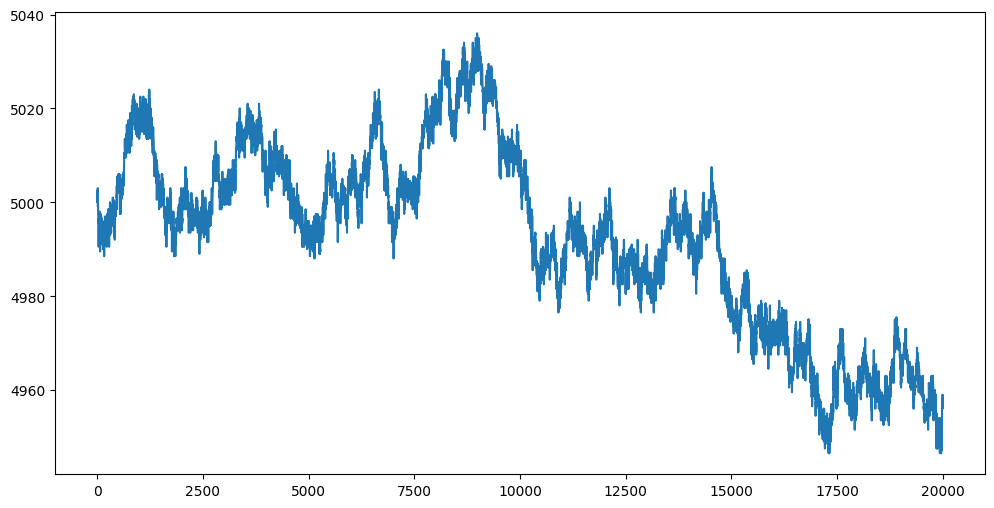

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices.index, tom_prices["mid_price"])

In [7]:
tom_prices["returns"] = tom_prices["mid_price"].diff()

print(tom_prices["returns"].describe())

count    19999.000000
mean        -0.002150
std          1.341035
min         -8.500000
25%         -0.500000
50%          0.000000
75%          0.500000
max          7.500000
Name: returns, dtype: float64


<Axes: >

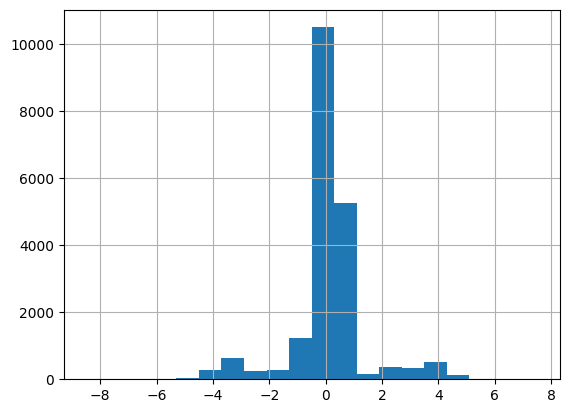

In [8]:
tom_prices["returns"].hist(bins=20)

In [9]:
tom_prices["up_move"] = tom_prices["returns"] > 0
tom_prices["down_move"] = tom_prices["returns"] < 0

print("Up after up:", (tom_prices["up_move"] & tom_prices["up_move"].shift(1)).mean())
print("Down after down:", (tom_prices["down_move"] & tom_prices["down_move"].shift(1)).mean())

Up after up: 0.0928
Down after down: 0.0959


In [10]:
tom_prices["mean"] = tom_prices["mid_price"].rolling(20).mean()
tom_prices["dev"] = tom_prices["mid_price"] - tom_prices["mean"]

In [11]:
tom_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,mid_price,profit_and_loss,global_time,bid_volume,ask_volume,returns,up_move,down_move,mean,dev
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,...,5000.0,0.0,-2000000,NaN,NaN,NaN,False,False,NaN,NaN
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,...,5002.5,0.0,-1999900,28.0,NaN,2.5,True,False,NaN,NaN
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,...,5001.0,0.0,-1999800,NaN,NaN,-1.5,False,True,NaN,NaN
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,...,5001.5,0.0,-1999700,NaN,NaN,0.5,True,False,NaN,NaN
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,...,5001.5,0.0,-1999600,NaN,NaN,0.0,False,False,NaN,NaN


In [ ]:
for price in tom_prices:
    

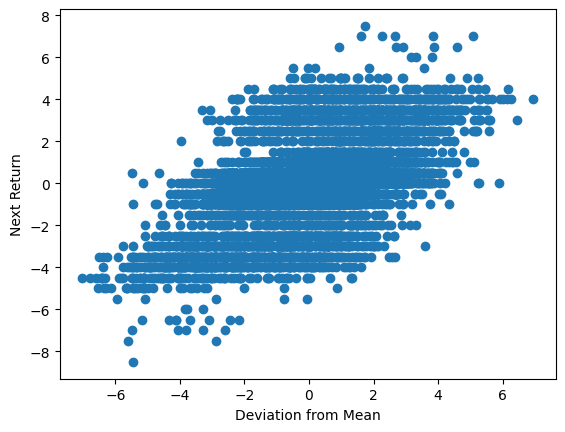

In [12]:
plt.scatter(tom_prices["dev"], tom_prices["returns"])
plt.xlabel("Deviation from Mean")
plt.ylabel("Next Return")
plt.show()

In [13]:
tom_prices["spread"] = tom_prices["ask_price_1"] - tom_prices["bid_price_1"]

tom_prices["spread"].describe()

count    20000.000000
mean        13.020250
std          1.754592
min          5.000000
25%         13.000000
50%         13.000000
75%         14.000000
max         14.000000
Name: spread, dtype: float64

In [14]:
tom_prices["vol"] = tom_prices["returns"].rolling(20).std()

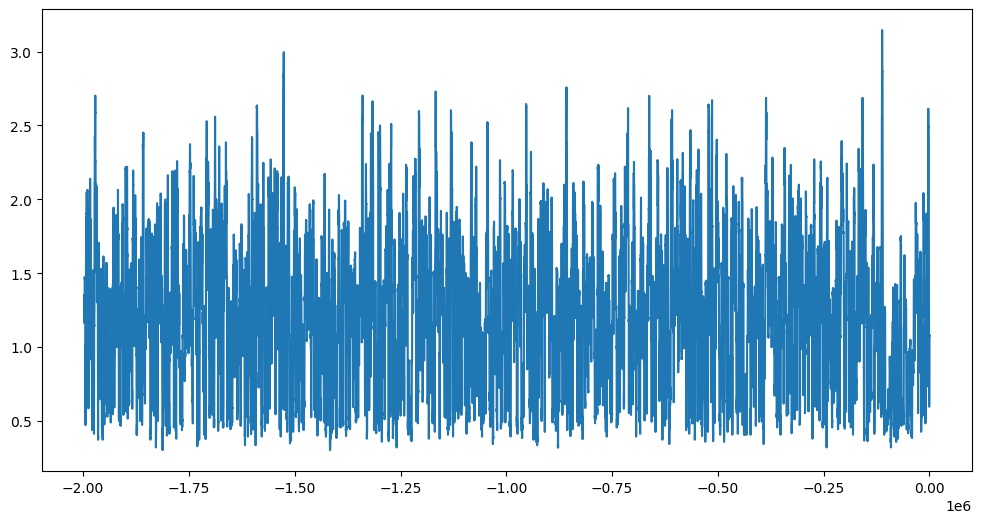

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices["global_time"], tom_prices["vol"])

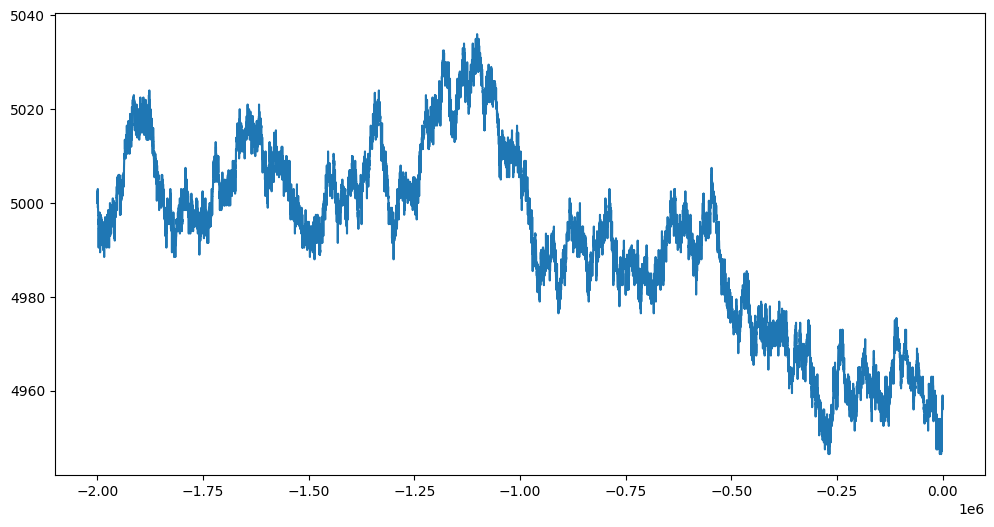

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(tom_prices["global_time"], tom_prices["mid_price"])

In [17]:
import numpy as np

def evaluate_window(prices, window, horizon=5):
    prices = np.array(prices)

    rolling_mean = pd.Series(prices).rolling(window).mean().values
    signal = prices - rolling_mean

    future_returns = np.roll(prices, -horizon) - prices

    # remove invalid rows
    mask = ~np.isnan(signal)
    mask &= ~np.isnan(future_returns)

    signal = signal[mask]
    future_returns = future_returns[mask]

    # correlation between signal and future return
    corr = np.corrcoef(signal, future_returns)[0, 1]

    # mean PnL if we traded this signal
    pnl = -np.sign(signal) * future_returns
    avg_pnl = np.mean(pnl)

    return corr, avg_pnl

In [18]:
results = []

for w in range(2, 50):
    corr, pnl = evaluate_window(tom_prices["mid_price"], window=w, horizon=5)
    results.append((w, corr, pnl))

results_df = pd.DataFrame(results, columns=["window", "correlation", "avg_pnl"])

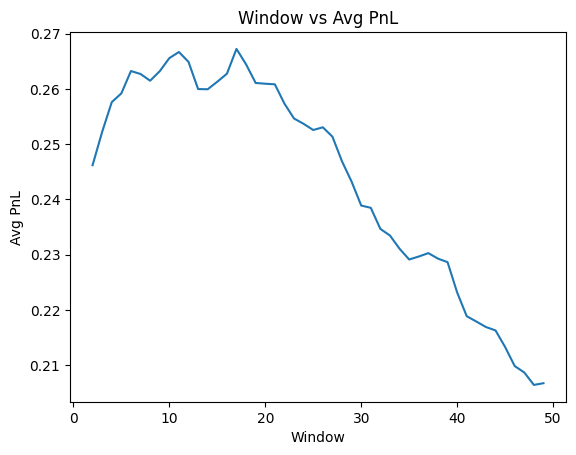

In [19]:
plt.plot(results_df["window"], results_df["avg_pnl"])
plt.title("Window vs Avg PnL")
plt.xlabel("Window")
plt.ylabel("Avg PnL")
plt.show()

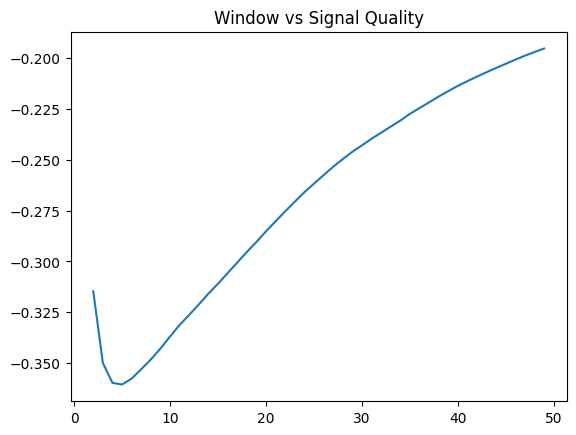

In [20]:
plt.plot(results_df["window"], results_df["correlation"])
plt.title("Window vs Signal Quality")
plt.show()

In [21]:
def evaluate_with_threshold(prices, window, threshold=2, horizon=5):
    prices = np.array(prices)
    rolling_mean = pd.Series(prices).rolling(window).mean().values

    signal = prices - rolling_mean
    future_returns = np.roll(prices, -horizon) - prices

    mask = ~np.isnan(signal)
    mask &= ~np.isnan(future_returns)

    signal = signal[mask]
    future_returns = future_returns[mask]

    trades = np.abs(signal) > threshold

    if trades.sum() == 0:
        return 0

    pnl = -np.sign(signal[trades]) * future_returns[trades]
    return np.mean(pnl)

In [22]:
evaluate_with_threshold(tom_prices["mid_price"], 8)

np.float64(2.830007127583749)

ML Stuff

In [23]:
tom_prices_ml = tom_prices.drop(['returns',
                             'bid_volume',
                             'ask_volume',
                             'up_move',
                             'down_move',
                             'dev',
                             'vol',
                             'product',
                             'bid_price_3',
                             'bid_volume_3',
                             'ask_price_3',
                             'ask_volume_3',
                             'profit_and_loss',
                             'mean',
                             'day',
                             'timestamp'],
                             axis=1)

tom_prices_ml = tom_prices_ml.set_index('global_time')

In [24]:
tom_prices_ml['lev_1_volume'] = tom_prices_ml['bid_volume_1'] + tom_prices_ml['ask_volume_1']
tom_prices_ml['lev_2_volume'] = tom_prices_ml['bid_volume_2'] + tom_prices_ml['ask_volume_2']
tom_prices_ml['regime'] = ((tom_prices_ml['bid_volume_1'] - tom_prices_ml['ask_volume_1']) /
                           (tom_prices_ml['bid_volume_1'] + tom_prices_ml['ask_volume_1']))
tom_prices_ml['mean'] = tom_prices_ml["mid_price"].rolling(20).mean()
tom_prices_ml['dev'] = tom_prices_ml["mid_price"] - tom_prices_ml['mean']
tom_prices_ml['y'] = np.sign(np.log(tom_prices_ml['mid_price'] / tom_prices_ml['mid_price'].shift(1)))
tom_prices_ml = tom_prices_ml.dropna()

In [25]:
tom_prices_ml.head(6)

,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,mid_price,spread,lev_1_volume,lev_2_volume,regime,mean,dev,y
global_time,,,,,,,,,,,,,,,,
-1998100,4992,7,4991,17,5005,7,5007,17,4998.5,13,14,34,0.0,5000.375,-1.875,-1.0
-1998000,4992,10,4990,17,5005,10,5006,17,4998.5,13,20,34,0.0,5000.300,-1.800,0.0
-1997900,4991,10,4990,20,5005,10,5006,20,4998.0,14,20,40,0.0,5000.075,-2.075,-1.0
-1997800,4991,5,4989,19,5004,5,5005,19,4997.5,13,10,38,0.0,4999.900,-2.400,-1.0
-1997700,4991,7,4989,22,5004,7,5005,22,4997.5,13,14,44,0.0,4999.700,-2.200,0.0
-1997600,4991,7,4989,18,5004,7,5005,18,4997.5,13,14,36,0.0,4999.500,-2.000,0.0


In [26]:
tom_prices_ml['y'].value_counts(1)

y
-1.0    0.340674
 1.0    0.338321
 0.0    0.321005
Name: proportion, dtype: float64

In [27]:
X = tom_prices_ml.drop(columns=['y'])
y = tom_prices_ml['y']

In [28]:
split = int(len(tom_prices_ml) * .8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [29]:
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler(feature_range=(-1, 1))
X_train_min_max = min_max.fit_transform(X_train)
X_test_min_max = min_max.fit_transform(X_test)

In [30]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.fit_transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_min_max, y_train)
model.fit(X_train_std, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=11)
sgd_clf.fit(X_train_min_max, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [33]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=11)
sgd_clf.fit(X_train_min_max, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [34]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_std)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4553415061295972


In [35]:
y_pred_sgd = sgd_clf.predict(X_test_std)

print("Accuracy:", accuracy_score(y_test, y_pred_sgd))

Accuracy: 0.4706029522141606


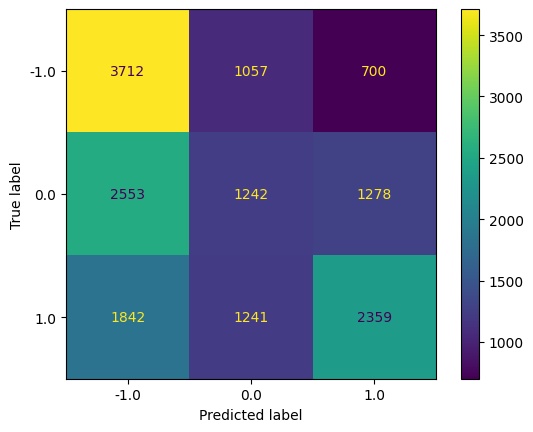

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_pred_sgd = cross_val_predict(sgd_clf, X_train_std, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_sgd)

In [37]:
X1 = tom_prices_ml.drop(columns=['y', 'spread'])
y1 = tom_prices_ml['spread']

In [38]:
X1_train = X1.iloc[:split]
X1_test = X1.iloc[split:]

y1_train = y1.iloc[:split]
y1_test = y1.iloc[split:]

In [39]:
std_scaler = StandardScaler()
X1_train_std = std_scaler.fit_transform(X1_train)
X1_test_std = std_scaler.fit_transform(X1_test)

In [40]:
sgd_clf1 = SGDClassifier(random_state=11)
sgd_clf1.fit(X1_train_std, y1_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [41]:
y_pred_sgd1 = sgd_clf1.predict(X1_test_std)

print("Accuracy:", accuracy_score(y1_test, y_pred_sgd1))

Accuracy: 0.8493870402802102


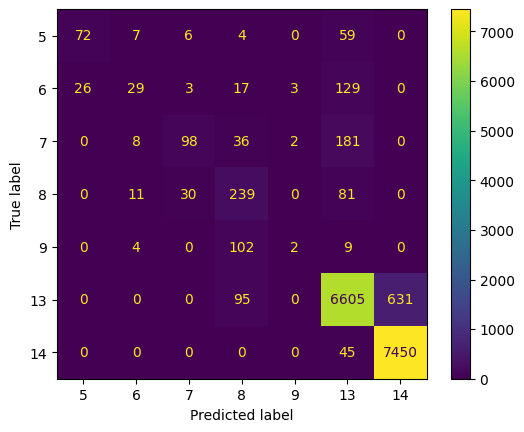

In [42]:
y_pred_sgd1 = cross_val_predict(sgd_clf1, X1_train_std, y1_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y1_train, y_pred_sgd1)